In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from transformers import RobertaTokenizer, RobertaModel
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from torch.utils.data import DataLoader, Subset
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.exceptions import FitFailedWarning
import warnings
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib
from sklearn.base import clone

In [2]:
import torch

# 检查是否有可用的 GPU
if torch.cuda.is_available():
    print("CUDA 可用，GPU 可用。")
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
    print(f"当前设备名称: {torch.cuda.get_device_name(0)}")
    print(f"当前设备总内存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA 不可用，仅支持 CPU。")


CUDA 可用，GPU 可用。
CUDA 版本: 12.1
GPU 数量: 1
当前设备名称: NVIDIA GeForce RTX 4090 D
当前设备总内存: 23.64 GB


In [22]:
data=pd.read_excel("./invertebrates_EC10.xlsx")
data=data.dropna()
smiles_data = data['SMILES_Canonical_RDKit'].tolist()
mgperL = data['mgperL'].values
Duration_Value= data['Duration_Value'].values

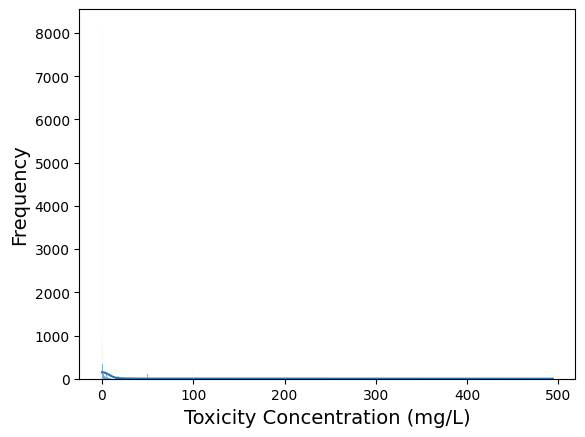

In [4]:

# 假设 mgperL 是毒性浓度数据的列表或数组
sns.histplot(mgperL, kde=True)
#plt.title('Original Toxicity Concentration Distribution')
plt.xlabel('Toxicity Concentration (mg/L)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()



In [5]:
# 统计信息
mean = np.mean(mgperL)
median = np.median(mgperL)
std_dev = np.std(mgperL)
print(f"Mean: {mean}, Median: {median}, Std Dev: {std_dev}")

Mean: 13.818039206563693, Median: 0.16, Std Dev: 46.28314455102204


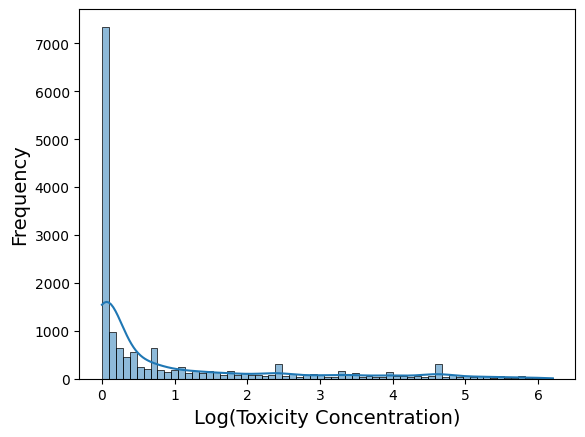

In [6]:
# 应用 log1p 变换并再次查看分布
log_mgperL = np.log1p(mgperL)
sns.histplot(log_mgperL, kde=True)
#plt.title('Log-transformed Toxicity Concentration Distribution')
plt.xlabel('Log(Toxicity Concentration)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

In [7]:
mgperL=np.log1p(mgperL)

In [23]:
# 数据增强函数：简单的 SMILES 序列翻转
def augment_smiles(smiles):
    """简单的数据增强方法，例如旋转 SMILES 字符串"""
    if random.random() > 0.5:
        return smiles[::-1]  # 翻转字符串
    return smiles

# 根据 mgperL 浓度生成分类标签
def generate_labels(mgperL):
    """根据 mgperL 的浓度范围生成分类标签"""
    if mgperL < 0.05:
        return 0  # high
    elif 0.05 <= mgperL < 1:
        return 1  # mid
    elif 1 <= mgperL < 2.5:
        return 2  # mid
    else:
        return 3  # low

# 数据集定义
class SMILES_Dataset(Dataset):
    def __init__(self, smiles, reg_labels, class_labels):
        self.smiles = smiles
        self.reg_labels = reg_labels  # 回归任务标签 (mgperL)
        self.class_labels = class_labels  # 分类任务标签

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        #smiles = augment_smiles(self.smiles[idx])  # 数据增强
        smiles = self.smiles[idx]  # 数据增强
        reg_label = self.reg_labels[idx]
        class_label = self.class_labels[idx]
        tokens = tokenizer(smiles, padding='max_length', truncation=True, max_length=128, return_tensors="pt")
        return tokens, torch.tensor(reg_label, dtype=torch.float32), torch.tensor(class_label, dtype=torch.long)

# 多任务模型定义
class ChemBERTa_MultiTask(nn.Module):
    def __init__(self, num_classes):
        super(ChemBERTa_MultiTask, self).__init__()
        # 加载预训练的ChemBERTa模型
        self.chemberta = chemberta_model
        hidden_size = self.chemberta.config.hidden_size  # 一般为768
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

        # 分类任务的全连接层
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4)
        )

    def forward(self, tokens):
        output = self.chemberta(**tokens)
        cls_embedding = output.last_hidden_state[:, 0, :]  # [CLS] token 嵌入
        reg_output = self.regressor(cls_embedding)  # 回归任务输出
        class_output = self.classifier(cls_embedding)  # 分类任务输出
        return reg_output, class_output

In [24]:
# 加载 ChemBERTa 模型和 tokenizer
model_name = "../models/chemBERTa"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
chemberta_model = RobertaModel.from_pretrained(model_name)

In [10]:
# 生成分类标签    
classification_labels = [generate_labels(mg) for mg in mgperL]

# 加载数据集
dataset = SMILES_Dataset(smiles_data, mgperL, classification_labels)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32,drop_last=True)

In [11]:

# 如果 classification_labels 是列表，先将其转换为 Series
classification_labels_series = pd.Series(classification_labels)

# 计算各类别的数目
class_counts = classification_labels_series.value_counts()
class_counts

0    5950
1    5518
3    2321
2    2124
Name: count, dtype: int64

In [25]:
# 初始化多任务模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ChemBERTa_MultiTask(chemberta_model).to(device)

In [13]:



# 损失函数
reg_criterion = nn.L1Loss()  # 回归任务的损失
class_criterion = nn.CrossEntropyLoss()  # 分类任务的损失

# 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# 训练模型
num_epochs = 100
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0



for epoch in range(num_epochs):
    model.train()
    running_reg_loss = 0.0
    running_class_loss = 0.0
    
    # 使用 tqdm 包装 train_loader
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Training")
    for tokens, reg_labels, class_labels in train_loader_tqdm:
        tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
        reg_labels = reg_labels.to(device)
        class_labels = class_labels.to(device)

        # 前向传播
        optimizer.zero_grad()
        reg_output, class_output = model(tokens)

        # 计算回归和分类任务的损失
        reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
        class_loss = class_criterion(class_output, class_labels)

        # 总损失
        loss = reg_loss + class_loss
        loss.backward()
        optimizer.step()

        running_reg_loss += reg_loss.item()
        running_class_loss += class_loss.item()
        
        # 在 tqdm 显示平均损失
        train_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item(), 'Class Loss': class_loss.item()})

    avg_reg_loss = running_reg_loss / len(train_loader)
    avg_class_loss = running_class_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Reg Loss: {avg_reg_loss:.4f}, Train Class Loss: {avg_class_loss:.4f}")

    # 验证模型
    model.eval()
    val_reg_loss = 0.0
    val_class_loss = 0.0
    correct_class_preds = 0
    total_class_preds = 0
    all_preds = []
    all_labels = []
    
    val_loader_tqdm = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] - Validation")
    with torch.no_grad():
        for tokens, reg_labels, class_labels in val_loader_tqdm:
            tokens = {key: val.squeeze(1).to(device) for key, val in tokens.items()}
            reg_labels = reg_labels.to(device)
            class_labels = class_labels.to(device)

            # 前向传播
            reg_output, class_output = model(tokens)

            # 计算回归和分类任务的损失
            reg_loss = reg_criterion(reg_output.squeeze(), reg_labels)
            class_loss = class_criterion(class_output, class_labels)
            val_reg_loss += reg_loss.item()
            val_class_loss += class_loss.item()

            # 计算分类准确率
            _, predicted = torch.max(class_output, 1)
            correct_class_preds += (predicted == class_labels).sum().item()
            total_class_preds += class_labels.size(0)

            all_preds.extend(reg_output.squeeze().cpu().numpy())
            all_labels.extend(reg_labels.cpu().numpy())
            
            # 在 tqdm 显示平均损失
            val_loader_tqdm.set_postfix({'Reg Loss': reg_loss.item(), 'Class Loss': class_loss.item()})

    avg_val_reg_loss = val_reg_loss / len(val_loader)
    avg_val_class_loss = val_class_loss / len(val_loader)
    val_accuracy = correct_class_preds / total_class_preds
    val_r2 = r2_score(np.expm1(all_labels), np.expm1(all_preds))  # 还原 log1p 的值

    print(f"Val Reg Loss: {avg_val_reg_loss:.4f}, Val Class Loss: {avg_val_class_loss:.4f}, Val R²: {val_r2:.4f}, Val Accuracy: {val_accuracy:.4f}, Early Stop Counter: {early_stop_counter}")

    # 早停机制
    if avg_val_reg_loss < best_val_loss:
        best_val_loss = avg_val_reg_loss
        early_stop_counter = 0  # 重置早停计数器
        torch.save(model.state_dict(), './invertebrates_EC10_1.pth')  # 保存最好的模型
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"早停触发，在第 {epoch+1} 个 epoch 停止训练")
            break


Epoch [1/100] - Training: 100%|██████████| 397/397 [00:22<00:00, 17.54it/s, Reg Loss=1.06, Class Loss=1.22]  


Epoch [1/100], Train Reg Loss: 0.9262, Train Class Loss: 1.2469


Epoch [1/100] - Validation: 100%|██████████| 99/99 [00:02<00:00, 38.36it/s, Reg Loss=0.534, Class Loss=0.962]


Val Reg Loss: 0.7410, Val Class Loss: 1.0770, Val R²: -0.0445, Val Accuracy: 0.4978, Early Stop Counter: 0


Epoch [2/100] - Training: 100%|██████████| 397/397 [00:22<00:00, 17.54it/s, Reg Loss=0.773, Class Loss=1.05] 


...

Val Reg Loss: 0.5001, Val Class Loss: 0.8959, Val R²: 0.2778, Val Accuracy: 0.6477, Early Stop Counter: 3


Epoch [38/100] - Training: 100%|██████████| 397/397 [00:22<00:00, 17.76it/s, Reg Loss=0.357, Class Loss=0.687]


Epoch [38/100], Train Reg Loss: 0.4213, Train Class Loss: 0.6716


Epoch [38/100] - Validation: 100%|██████████| 99/99 [00:02<00:00, 39.90it/s, Reg Loss=0.302, Class Loss=0.611]

Val Reg Loss: 0.5022, Val Class Loss: 0.8980, Val R²: 0.2843, Val Accuracy: 0.6439, Early Stop Counter: 4
早停触发，在第 38 个 epoch 停止训练


In [26]:
# 加载最佳模型
model.load_state_dict(torch.load('./invertebrates_EC10_4.pth'))

<All keys matched successfully>

In [27]:


# 提取 SMILES 的嵌入表示

# 提取 SMILES 的嵌入表示
def extract_embeddings(smiles_list, model, tokenizer, device):
    embeddings = []
    model.eval()  # 设置模型为评估模式
    with torch.no_grad():
        for smiles in smiles_list:
            # Tokenize the SMILES string
            tokens = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            
            # 通过 ChemBERTa 模型获得输出
            outputs = model.chemberta(**tokens)  # 提取 ChemBERTa 模型的输出
            
            # 提取 [CLS] token 的嵌入作为 SMILES 的整体嵌入
            cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # 获取多维的 [CLS] 嵌入
            embeddings.append(cls_embedding)
    
    return np.vstack(embeddings)  # 将所有嵌入拼接成一个矩阵

# 提取嵌入
smiles_embeddings = extract_embeddings(smiles_data, model, tokenizer, device)

In [38]:
# 使用 PCA 对嵌入进行降维，同时获取主成分的解释方差百分比
def apply_pca(embeddings, n_components=2):
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(embeddings)
    explained_variance = pca.explained_variance_ratio_  # 获取每个主成分的解释方差
    return pca_result, explained_variance

# 可视化函数，同时显示解释方差百分比
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis', alpha=0.7,s=10)
    plt.colorbar(scatter, label='mgperL')
    #plt.title(f'PCA of SMILES Embeddings with mgperL Heatmap\n'
    #          f'Explained Variance: PC1: {explained_variance[0]*100:.2f}%, PC2: {explained_variance[1]*100:.2f}%')
    plt.xlabel(f'PCA Component 1 ({explained_variance[0]*100:.2f}% variance)', fontsize=14)
    plt.ylabel(f'PCA Component 2 ({explained_variance[1]*100:.2f}% variance)', fontsize=14)
    plt.show()


# 使用 PCA 降维，并获取解释方差
pca_result, explained_variance = apply_pca(smiles_embeddings, n_components=2)

In [39]:
# 创建 DataFrame 用于处理重复值
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['mgperL'] = data['mgperL'].values

# 去重并计算相同 PCA 结果的中位数 mgperL
unique_pca_df = pca_df.groupby(['PC1', 'PC2'])['mgperL'].median().reset_index()

ValueError: Length of values (15913) does not match length of index (15938)

In [ ]:
PCA_DF = unique_pca_df[['PC1', 'PC2']]

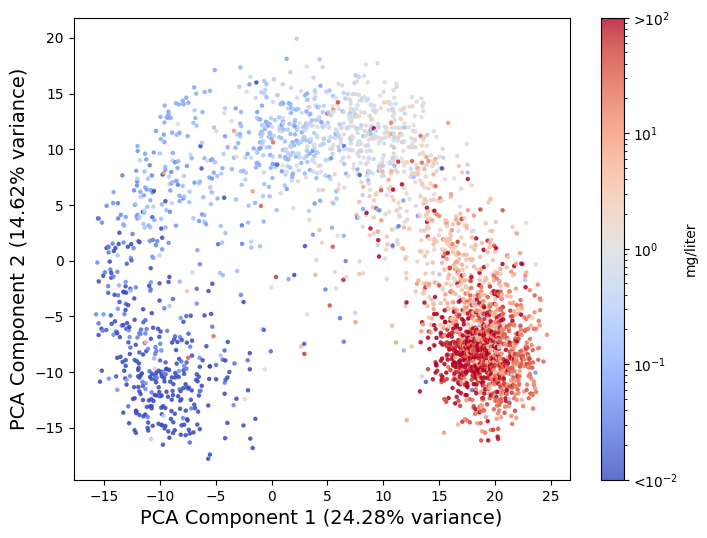

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 可视化函数，同时显示解释方差百分比
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6))

    # 使用 LogNorm 创建对数色标
    scatter = plt.scatter(
        pca_result['PC1'], pca_result['PC2'], 
        c=labels, 
        cmap='coolwarm',  # 可更换成其他配色
        norm=LogNorm(vmin=0.01, vmax=100),  # 设置对数刻度，0.01和100为最深颜色
        alpha=0.8, s=5
    )

    # 添加颜色条并设置刻度
    cbar = plt.colorbar(scatter, label='mg/liter')
    cbar.set_ticks([0.01, 0.1, 1, 10, 100])  # 设置对数刻度的主要刻度
    cbar.set_ticklabels([r'<10$^{-2}$', r'10$^{-1}$', r'10$^{0}$', r'10$^{1}$', r'>10$^{2}$'])  # 自定义标签

    plt.xlabel(f'PCA Component 1 ({explained_variance[0]*100:.2f}% variance)', fontsize=14)
    plt.ylabel(f'PCA Component 2 ({explained_variance[1]*100:.2f}% variance)', fontsize=14)
    
    plt.show()
plot_pca_with_variance(PCA_DF, unique_pca_df['mgperL'], explained_variance)

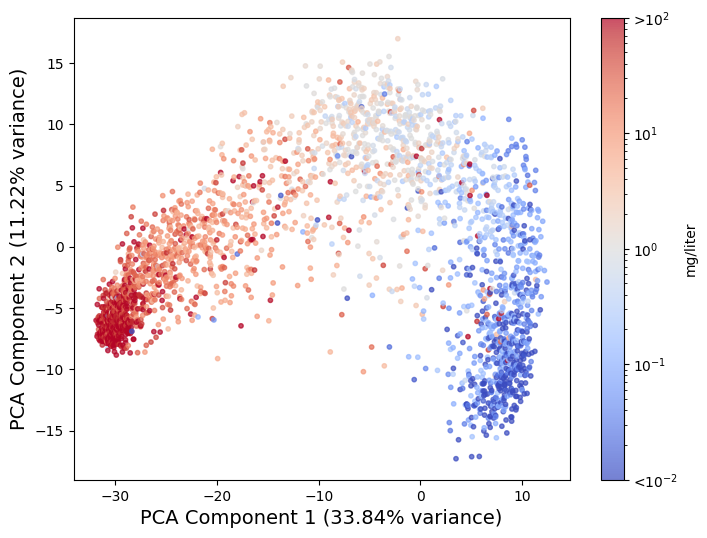

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 可视化函数，同时显示解释方差百分比
def plot_pca_with_variance(pca_result, labels, explained_variance):
    plt.figure(figsize=(8, 6))

    # 使用 LogNorm 创建对数色标
    scatter = plt.scatter(
        pca_result['PC1'], pca_result['PC2'], 
        c=labels, 
        cmap='coolwarm',  # 可更换成其他配色
        norm=LogNorm(vmin=0.01, vmax=100),  # 设置对数刻度，0.01和100为最深颜色
        alpha=0.7, s=10
    )
##################11111111111111111111111
    # 添加颜色条并设置刻度
    cbar = plt.colorbar(scatter, label='mg/liter')
    cbar.set_ticks([0.01, 0.1, 1, 10, 100])  # 设置对数刻度的主要刻度
    cbar.set_ticklabels([r'<10$^{-2}$', r'10$^{-1}$', r'10$^{0}$', r'10$^{1}$', r'>10$^{2}$'])  # 自定义标签

    plt.xlabel(f'PCA Component 1 ({explained_variance[0]*100:.2f}% variance)', fontsize=14)
    plt.ylabel(f'PCA Component 2 ({explained_variance[1]*100:.2f}% variance)', fontsize=14)
    
    plt.show()
plot_pca_with_variance(PCA_DF, unique_pca_df['mgperL'], explained_variance)

In [33]:
np.save('./invertebrates_EC10_smiles_embeddings_zzz.npy', smiles_embeddings)

In [37]:
smiles_embeddings = np.load('./invertebrates_EC10_smiles_embeddings_4.npy')

In [21]:
data=pd.read_excel("./invertebrates_EC10.xlsx")
data=data.dropna()
smiles_data = data['SMILES_Canonical_RDKit'].tolist()
mgperL = data['mgperL'].values
Duration_Value= data['Duration_Value'].values

In [6]:




 # 检查effect列的唯一值
unique_effects = data['effect'].unique()

# 如果effect列有多于一种类别，则进行One-Hot编码
if len(unique_effects) > 1:
    encoder = OneHotEncoder(sparse_output=False)
    effect_encoded = encoder.fit_transform(data[['effect']])
else:
    effect_encoded = None  # 只有一种类别时忽略


# 检查endpoint列的唯一值
unique_endpoint = data['endpoint'].unique()

# 如果endpoint列有多于一种类别，则进行One-Hot编码
if len(unique_endpoint) > 1:
    encoder = OneHotEncoder(sparse_output=False)
    endpoint_encoded = encoder.fit_transform(data[['endpoint']])
else:
    endpoint_encoded = None  # 只有一种类别时忽略


# 拼接 Duration_Value 和 effect（如果有）
X = np.hstack((smiles_embeddings, data['Duration_Value'].values.reshape(-1, 1)))

if effect_encoded is not None:
    X = np.hstack((X, effect_encoded))
    
if endpoint_encoded is not None:
    X = np.hstack((X, endpoint_encoded))


# 目标值 mgperL
y = mgperL
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 初始化 scaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 对 X_train 和 y_train 进行标准化
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [24]:


from tqdm import tqdm
from sklearn.exceptions import FitFailedWarning
import warnings
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
# 导入模型
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# 导入超参数优化工具
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import matplotlib
from sklearn.base import clone





In [25]:



def perform_random_search(model, param_grid, X_train, y_train, X_test, y_test, n_iter=20):
    param_iter = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
    with tqdm(total=len(param_iter), desc="Hyperparameter Search") as pbar:
        best_score = float('inf')
        best_model = None
        best_params = None

        for params in param_iter:
            try:
                temp_model = clone(model)
                temp_model.set_params(**params)
                temp_model.fit(X_train, y_train)
                y_pred = temp_model.predict(X_test)
                mse = mean_squared_error(y_test, y_pred)
                if mse < best_score:
                    best_score = mse
                    best_model = temp_model
                    best_params = params
            except Exception as e:
                warnings.warn(f"Fit failed for parameters {params}: {e}", FitFailedWarning)
            pbar.update(1)

    return best_model, best_params

# Define models and expanded parameter grids
mlp = MLPRegressor(max_iter=1000)
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (50, 50), (100, 50), (50, 100), (100, 100), (150, 100, 50)],
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'solver': ['lbfgs', 'sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01, 0.1]
}

xgb = XGBRegressor()
xgb_param_grid = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm = LGBMRegressor(verbose=-1)
lgbm_param_grid = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 70, 100],
    'feature_fraction': [0.6, 0.8, 1.0],
    'bagging_fraction': [0.6, 0.8, 1.0]
}

# Assume X_train, X_test, y_train, y_test are already defined
# Split your dataset here if not already done
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models and evaluate
models = {
    'DNN': (mlp, mlp_param_grid),
    'XGBoost': (xgb, xgb_param_grid),
    'LightGBM': (lgbm, lgbm_param_grid)
}

best_params_dict = {}  # To store best parameters for each model
best_models = {}       # To store the best model for each

for name, (model, param_grid) in models.items():
    print(f"\nTraining {name}...")
    best_model, best_params = perform_random_search(model, param_grid, X_train, y_train, X_test, y_test, n_iter=20)
    best_models[name] = best_model
    best_params_dict[name] = best_params
    print(f"{name} Best Parameters: {best_params}")



Training DNN...


Hyperparameter Search:  25%|██▌       | 5/20 [01:38<03:32, 14.15s/it]/root/miniconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
Hyperparameter Search:  35%|███▌      | 7/20 [02:46<05:09, 23.78s/it]/root/miniconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
Hyperparameter Search:  40%|████

DNN Best Parameters: {'solver': 'sgd', 'hidden_layer_sizes': (150, 100, 50), 'alpha': 0.0001, 'activation': 'logistic'}

Training XGBoost...


Hyperparameter Search: 100%|██████████| 20/20 [03:27<00:00, 10.39s/it]


XGBoost Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Training LightGBM...


Hyperparameter Search: 100%|██████████| 20/20 [01:52<00:00,  5.61s/it]

LightGBM Best Parameters: {'num_leaves': 70, 'n_estimators': 300, 'learning_rate': 0.01, 'feature_fraction': 0.8, 'bagging_fraction': 0.6}


In [26]:
def plot_prediction_map(y_test,y_pred):
    
    # 假设 y_test 是真实值, y_pred 是模型的预测值
    y_test = np.array(y_test)  # 替换为你的真实数据
    y_pred = np.array(y_pred)  # 替换为模型的预测数据
    
    # 计算预测误差
    errors = y_test - y_pred
    
    # 绘制误差分布图
    plt.figure(figsize=(8, 6))
    
    # 绘制误差的直方图
    sns.histplot(errors, color='blue', bins=30, stat="density", label='Error Distribution')
    
    # 计算误差的均值和标准差
    (mu, sigma) = norm.fit(errors)
    
    # 使用正态分布拟合曲线
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    
    # 绘制正态分布曲线
    plt.plot(x, p, 'k', linewidth=2, label=f'Normal Distribution\n($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})')
    
    # 添加0误差线
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    
    # 设置标题和标签，并调整字体大小
    plt.title('Error Distribution', fontsize=18)  # 增大标题字体
    plt.xlabel('Prediction Error', fontsize=14)  # 增大x轴标签字体
    plt.ylabel('Density', fontsize=14)  # 增大y轴标签字体
    
    # 调整图例字体大小，并设置图例位置
    plt.legend(fontsize=12, loc='upper right')  # 将图例放在右上角，增加字体大小
    
    # 调整坐标轴刻度字体大小
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # 显示图形
    plt.show()
    
    # 假设 y_true 是实际值，y_pred 是预测值
    y_true = np.array(y_test)  # 替换为你的实际数据
    
    # 计算回归线
    slope, intercept = np.polyfit(y_true, y_pred, 1)
    line = slope * y_true + intercept
    
    # 计算 RMSE 和 R²
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # 创建图形
    plt.figure(figsize=(8, 6))
    
    # 绘制散点图和回归线，带置信区间
    sns.regplot(x=y_true, y=y_pred, scatter_kws={'color': 'blue', 's': 20},
                line_kws={'color': 'red', 'label': f'y = {slope:.4f}x + {intercept:.4f}'})
    
    # 添加 RMSE 和 R² 到图表中，调整位置
    plt.text(0.8, 0.10, f'RMSE: {rmse:.3f}', fontsize=12, transform=plt.gca().transAxes)
    plt.text(0.8, 0.05, f'R²: {r2:.3f}', fontsize=12, transform=plt.gca().transAxes)
   
    
    # 设置图形标签
    plt.xlabel('Actual Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.title('Actual vs. Predicted', fontsize=16)
    # 显示图例
    plt.legend()
    # 显示图形
    plt.show()

In [7]:
def plot_fold_change_histogram_symmetric(y_true, y_pred):
    # 计算 fold change：预测值相对于真实值的倍数
    fold_change_pos = y_pred[y_pred >= y_true] / y_true[y_pred >= y_true]  # 预测值大于真实值
    fold_change_neg = y_true[y_pred < y_true] / y_pred[y_pred < y_true]    # 预测值小于真实值

    # 合并数据并生成单一的对数间隔
    fold_change_combined = np.concatenate((1/fold_change_neg, fold_change_pos))
    bins = np.logspace(-3, 3, 150)  # 增加分辨率，使用150个区间
    plt.figure(figsize=(10, 6))

    # 绘制直方图
    plt.hist(fold_change_combined, bins=bins, color='saddlebrown', edgecolor='black', alpha=0.7, 
             label="Residual Error (Prediction vs Actual)", rwidth=0.9)  # rwidth 调整间隙

    # 添加对数刻度和中心的1
    plt.xscale('log')
    plt.xlabel("Prediction error (fold change)", fontsize=14)
    plt.ylabel("Count", fontsize=14)
    #plt.title("Histograms of the residual errors (fold change)", fontsize=16)

    # 添加大于特定倍数误差的百分比标记
    thresholds = [10, 100, 1000]
    total_count_pos = len(fold_change_pos)
    total_count_neg = len(fold_change_neg)
    total_count_all = total_count_neg+total_count_pos
    
    for threshold in thresholds:
        # 计算右侧误差大于特定阈值的数量和百分比
        count_above_pos = np.sum(fold_change_pos > threshold)
        #percentage_pos = (count_above_pos / total_count_pos) * 100
        percentage_pos = (count_above_pos / total_count_all) * 100
        
        # 计算左侧误差大于特定阈值的数量和百分比
        count_above_neg = np.sum(fold_change_neg > threshold)
        #percentage_neg = (count_above_neg / total_count_neg) * 100
        percentage_neg = (count_above_neg / total_count_all) * 100
        
        # 在右侧标注阈值线和百分比
        plt.axvline(threshold, color='blue', linestyle='--', linewidth=1)
        plt.text(threshold, plt.ylim()[1] * 0.8, f"{percentage_pos:.1f}%", color="blue", ha="center", fontsize=10)

        # 在左侧标注阈值线和百分比
        plt.axvline(1/threshold, color='blue', linestyle='--', linewidth=1)
        plt.text(1/threshold, plt.ylim()[1] * 0.8, f"{percentage_neg:.1f}%", color="blue", ha="center", fontsize=10)

    # 设置 x 轴的对称 log 刻度
    plt.xticks([1e-3, 1e-2, 1e-1, 1, 10, 100, 1000], ["1000", "100", "10", "1", "10", "100", "1000"])
    plt.show()


DNN Test MSE: 1176.6726
DNN Test RMSE: 34.3027
DNN Test MAE: 16.7897
DNN Test R²: 0.5041

DNN Test Rearsonr R: 0.7187

EC50 Model - MAD: 7.161625331598 SEM: 0.8933528998713576


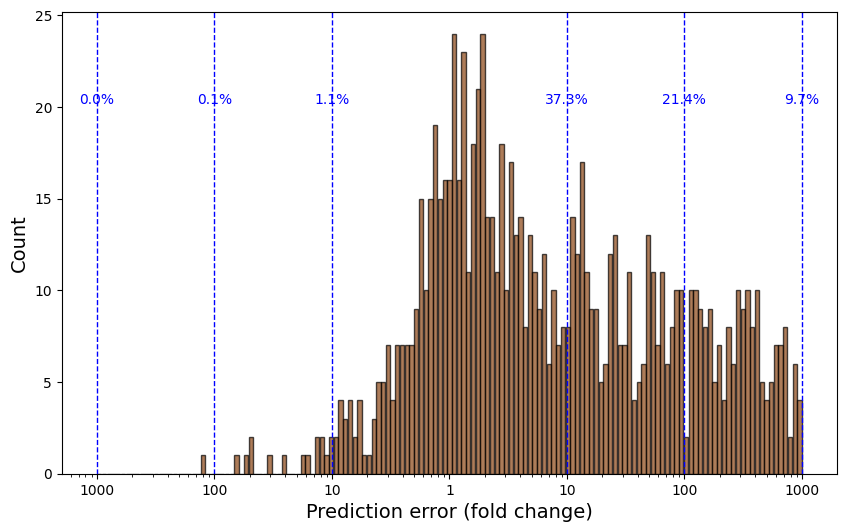

XGBoost Test MSE: 1140.0508
XGBoost Test RMSE: 33.7646
XGBoost Test MAE: 13.5250
XGBoost Test R²: 0.5195

XGBoost Test Rearsonr R: 0.7229

EC50 Model - MAD: 1.3588990783691415 SEM: 0.8800591374850352


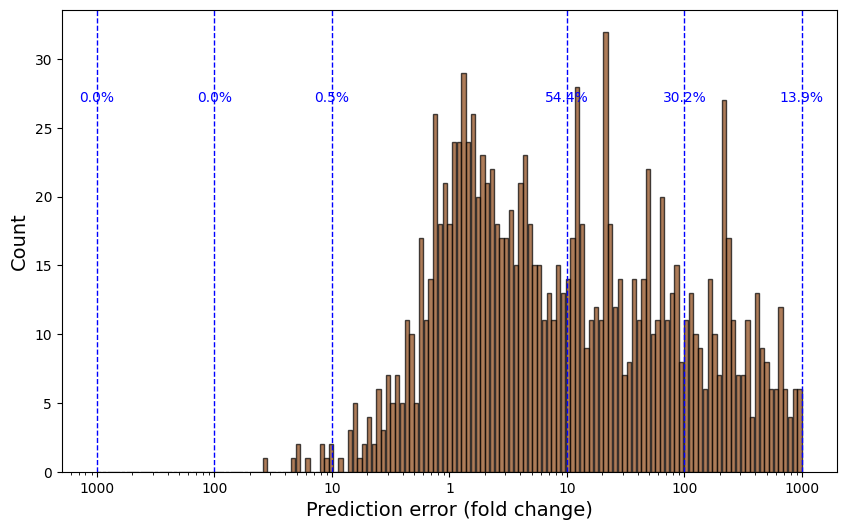

LightGBM Test MSE: 1158.7984
LightGBM Test RMSE: 34.0411
LightGBM Test MAE: 13.4161
LightGBM Test R²: 0.5116

LightGBM Test Rearsonr R: 0.7183

EC50 Model - MAD: 1.705658426275594 SEM: 0.887519674385132


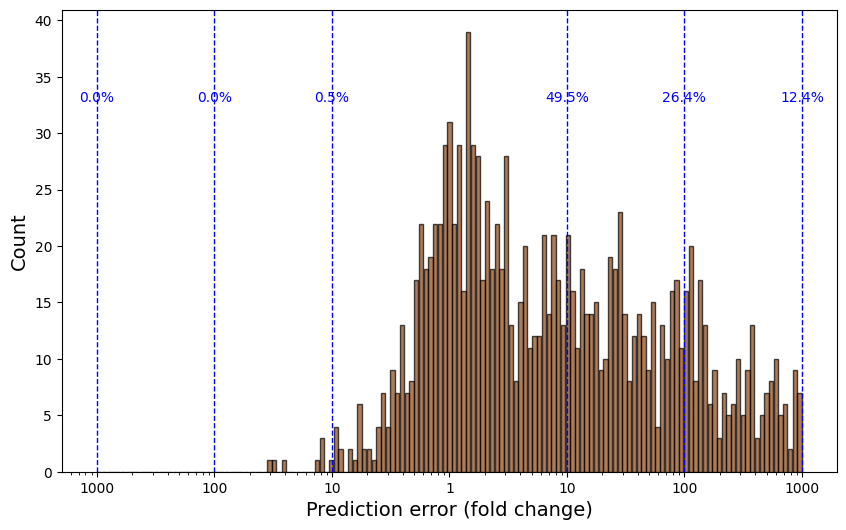

In [28]:
# 评估所有模型的性能
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # 对 y_pred 和 y_test 进行反标准化
    y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    
    # 计算评估指标
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)
    correlation, _ = pearsonr(y_test_original, y_pred_original)

    
    print(f"{name} Test MSE: {mse:.4f}")
    print(f"{name} Test RMSE: {rmse:.4f}")
    print(f"{name} Test MAE: {mae:.4f}")
    print(f"{name} Test R²: {r2:.4f}\n")
    print(f"{name} Test Rearsonr R: {correlation:.4f}\n")

    EC50_errors_data = y_test_original-y_pred_original
    # 计算 EC50 的 MAD 和 SEM
    EC50_median = np.median(EC50_errors_data)
    EC50_MAD = np.median(np.abs(EC50_errors_data - EC50_median))
    EC50_SEM = np.std(EC50_errors_data, ddof=1) / np.sqrt(len(EC50_errors_data))
    
    print("EC50 Model - MAD:", EC50_MAD, "SEM:", EC50_SEM)

    
    plot_fold_change_histogram_symmetric(y_test_original, y_pred_original)

In [ ]:
DNN Best Parameters: {'solver': 'sgd', 'hidden_layer_sizes': (150, 100, 50), 'alpha': 0.0001, 'activation': 'logistic'}

Training XGBoost...
Hyperparameter Search: 100%|██████████| 20/20 [03:27<00:00, 10.39s/it]
XGBoost Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Training LightGBM...
Hyperparameter Search: 100%|██████████| 20/20 [01:52<00:00,  5.61s/it]
LightGBM Best Parameters: {'num_leaves': 70, 'n_estimators': 300, 'learning_rate': 0.01, 'feature_fraction': 0.8, 'bagging_fraction': 0.6}


Evaluating XGBoost...
XGBoost Performance:
  MSE: 1140.0508
  RMSE: 33.7646
  MAE: 13.5250
  R^2: 0.5195
  Pearson Correlation: 0.7229
EC50 Model - MAD: 1.3588990783691415 SEM: 0.8800591374850352


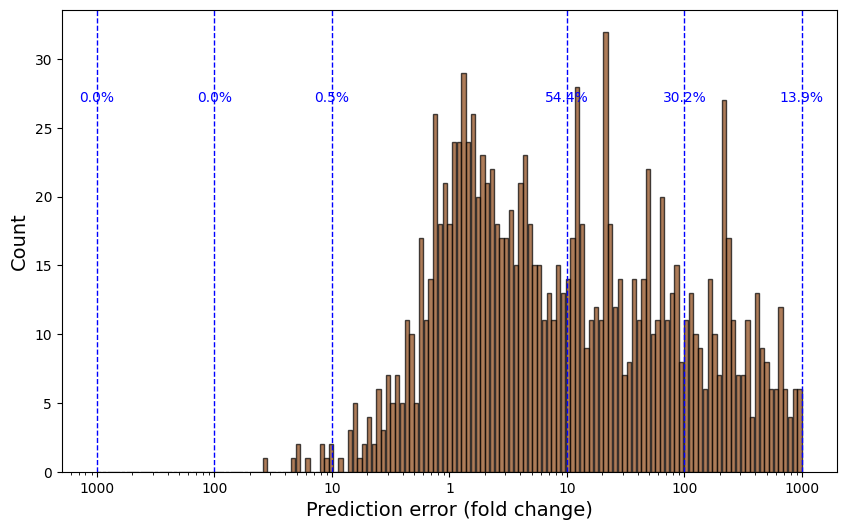

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

# 假设你已有的最优参数
best_params_dict = {
    'XGBoost': {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
}

# 定义模型
models = {
    'XGBoost': XGBRegressor(**best_params_dict['XGBoost'])
}

# 假设 scaler_y 是你的 y 数据的标准化缩放器
# scaler_y = StandardScaler().fit(y_train.reshape(-1, 1)) # 如果你之前没有定义 scaler_y，先标准化 y_train 数据

# 训练模型并进行评估
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # 训练模型
    model.fit(X_train, y_train)
    
    # 预测并反标准化
    y_pred = model.predict(X_test)
    y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    # 计算评估指标
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)
    correlation, _ = pearsonr(y_test_original, y_pred_original)
    
    # 输出结果
    print(f"{name} Performance:")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R^2: {r2:.4f}")
    print(f"  Pearson Correlation: {correlation:.4f}")


    EC50_errors_data = y_test_original-y_pred_original
    # 计算 EC50 的 MAD 和 SEM
    EC50_median = np.median(EC50_errors_data)
    EC50_MAD = np.median(np.abs(EC50_errors_data - EC50_median))
    EC50_SEM = np.std(EC50_errors_data, ddof=1) / np.sqrt(len(EC50_errors_data))
    
    print("EC50 Model - MAD:", EC50_MAD, "SEM:", EC50_SEM)
    plot_fold_change_histogram_symmetric(y_test_original, y_pred_original)

In [2]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler

# 假设你已有的最优参数
best_params_dict = {
    'DNN': {'solver': 'sgd', 'hidden_layer_sizes': (150, 100, 50), 'alpha': 0.0001, 'activation': 'logistic'},
    'XGBoost': {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8},
    'LightGBM': {'num_leaves': 70, 'n_estimators': 300, 'learning_rate': 0.01, 'feature_fraction': 0.8, 'bagging_fraction': 0.6}
}

# 定义模型
models = {
    'DNN': MLPRegressor(max_iter=1000, **best_params_dict['DNN']),
    'XGBoost': XGBRegressor(**best_params_dict['XGBoost']),
    'LightGBM': LGBMRegressor(verbose=-1, **best_params_dict['LightGBM'])
}

# 假设 scaler_y 是你的 y 数据的标准化缩放器
# scaler_y = StandardScaler().fit(y_train.reshape(-1, 1)) # 如果你之前没有定义 scaler_y，先标准化 y_train 数据

# 训练模型并进行评估
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # 训练模型
    model.fit(X_train, y_train)
    
    # 预测并反标准化
    y_pred = model.predict(X_test)
    y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    # 计算评估指标
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)
    correlation, _ = pearsonr(y_test_original, y_pred_original)
    
    # 输出结果
    print(f"{name} Performance:")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R^2: {r2:.4f}")
    print(f"  Pearson Correlation: {correlation:.4f}")


    EC50_errors_data = y_test_original-y_pred_original


    # 计算 EC50 的 MAD 和 SEM
    EC50_median = np.median(EC50_errors_data)
    EC50_MAD = np.median(np.abs(EC50_errors_data - EC50_median))
    EC50_SEM = np.std(EC50_errors_data, ddof=1) / np.sqrt(len(EC50_errors_data))
    
    print("EC50 Model - MAD:", EC50_MAD, "SEM:", EC50_SEM)


Evaluating DNN...


NameError: name 'X_train' is not defined

In [ ]:
)


In [29]:
# Updated parameter grids for further tuning

# For DNN
mlp_param_grid = {
    'hidden_layer_sizes': [(150, 100, 50), (160, 110, 60), (140, 90, 40)],  # Slight variations around (150, 100, 50)
    'activation': ['logistic', 'tanh'],  # Focused on logistic and tanh based on previous results
    'solver': ['sgd', 'adam'],  # Concentrate on sgd and adam
    'alpha': [0.00005, 0.0001, 0.0005]  # Narrower range around the best alpha 0.0001
}

# For XGBoost
xgb_param_grid = {
    'n_estimators': [250, 300, 350],  # Narrow range around 300
    'learning_rate': [0.005, 0.01, 0.02],  # Concentrating around 0.01
    'max_depth': [4, 5, 6],  # Narrow range around 5
    'subsample': [0.7, 0.8, 0.9],  # Focused around 0.8
    'colsample_bytree': [0.7, 0.8, 0.9]  # Focused around 0.8
}

# For LightGBM
lgbm_param_grid = {
    'n_estimators': [250, 300, 350],  # Narrow range around 300
    'learning_rate': [0.005, 0.01, 0.02],  # Concentrating around 0.01
    'num_leaves': [60, 70, 80],  # Narrow range around 70
    'feature_fraction': [0.75, 0.8, 0.85],  # Focused around 0.8
    'bagging_fraction': [0.55, 0.6, 0.65]  # Focused around 0.6
}

# Re-run the random search with the updated parameter grids
best_params_dict = {}  # To store best parameters for each model
best_models = {}       # To store the best model for each

for name, (model, param_grid) in models.items():
    print(f"\nTraining {name} with refined parameter grid...")
    best_model, best_params = perform_random_search(model, param_grid, X_train, y_train, X_test, y_test, n_iter=20)
    best_models[name] = best_model
    best_params_dict[name] = best_params
    print(f"{name} Refined Best Parameters: {best_params}")



Training DNN with refined parameter grid...


Hyperparameter Search:  25%|██▌       | 5/20 [01:40<03:42, 14.80s/it]/root/miniconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
Hyperparameter Search:  35%|███▌      | 7/20 [02:38<04:33, 21.03s/it]/root/miniconda3/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
Hyperparameter Search:  40%|████

DNN Refined Best Parameters: {'solver': 'sgd', 'hidden_layer_sizes': (150, 100, 50), 'alpha': 0.0001, 'activation': 'logistic'}

Training XGBoost with refined parameter grid...


Hyperparameter Search: 100%|██████████| 20/20 [03:28<00:00, 10.40s/it]


XGBoost Refined Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Training LightGBM with refined parameter grid...


Hyperparameter Search: 100%|██████████| 20/20 [01:51<00:00,  5.58s/it]

LightGBM Refined Best Parameters: {'num_leaves': 70, 'n_estimators': 300, 'learning_rate': 0.01, 'feature_fraction': 0.8, 'bagging_fraction': 0.6}


DNN Test MSE: 1164.9782
DNN Test RMSE: 34.1318
DNN Test MAE: 16.4545
DNN Test R²: 0.5090

DNN Test Rearsonr R: 0.7226

EC50 Model - MAD: 7.248443242497633 SEM: 0.8900559454313643


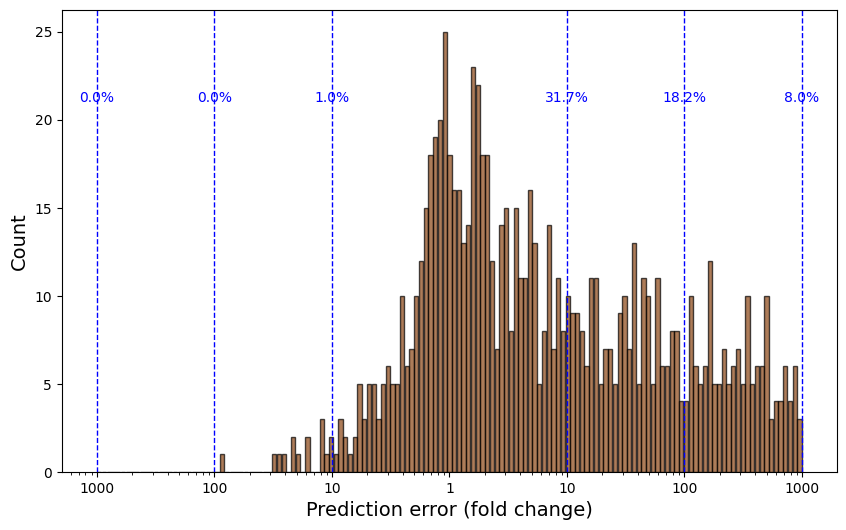

XGBoost Test MSE: 1140.0508
XGBoost Test RMSE: 33.7646
XGBoost Test MAE: 13.5250
XGBoost Test R²: 0.5195

XGBoost Test Rearsonr R: 0.7229

EC50 Model - MAD: 1.3588990783691415 SEM: 0.8800591374850352


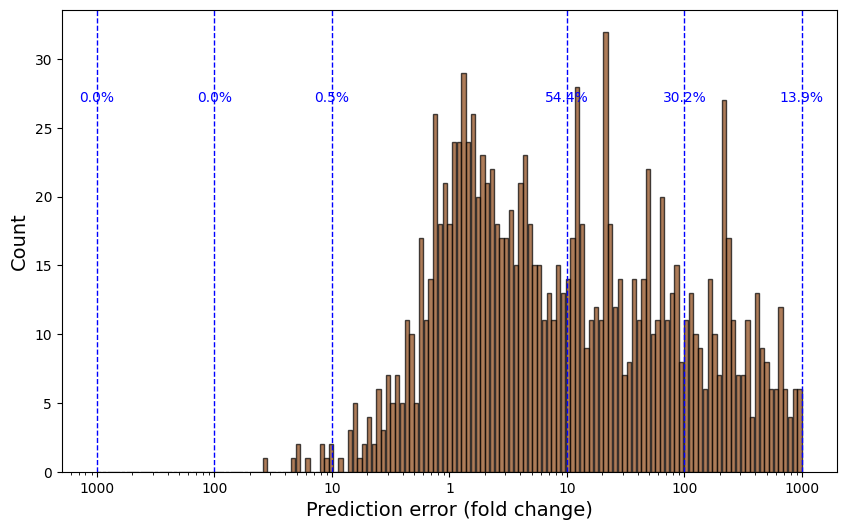

LightGBM Test MSE: 1158.7984
LightGBM Test RMSE: 34.0411
LightGBM Test MAE: 13.4161
LightGBM Test R²: 0.5116

LightGBM Test Rearsonr R: 0.7183

EC50 Model - MAD: 1.705658426275594 SEM: 0.887519674385132


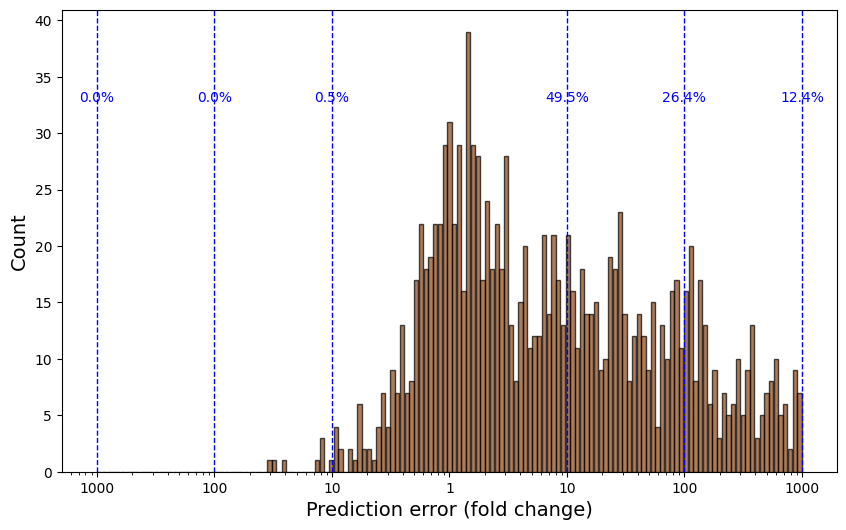

In [30]:
# 评估所有模型的性能
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    
    # 对 y_pred 和 y_test 进行反标准化
    y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    
    # 计算评估指标
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)
    correlation, _ = pearsonr(y_test_original, y_pred_original)

    
    print(f"{name} Test MSE: {mse:.4f}")
    print(f"{name} Test RMSE: {rmse:.4f}")
    print(f"{name} Test MAE: {mae:.4f}")
    print(f"{name} Test R²: {r2:.4f}\n")
    print(f"{name} Test Rearsonr R: {correlation:.4f}\n")

    EC50_errors_data = y_test_original-y_pred_original
    # 计算 EC50 的 MAD 和 SEM
    EC50_median = np.median(EC50_errors_data)
    EC50_MAD = np.median(np.abs(EC50_errors_data - EC50_median))
    EC50_SEM = np.std(EC50_errors_data, ddof=1) / np.sqrt(len(EC50_errors_data))
    
    print("EC50 Model - MAD:", EC50_MAD, "SEM:", EC50_SEM)

    
    plot_fold_change_histogram_symmetric(y_test_original, y_pred_original)

In [ ]:
#val_r2 = r2_score(np.expm1(all_labels), np.expm1(all_preds))  # 还原 log1p 的值